In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import colors
from tqdm import tqdm
from matplotlib.cm import ScalarMappable
from scipy.special import lambertw
from scipy.optimize import brentq
from scipy.optimize import minimize_scalar
import matplotlib as mpl
from scipy.optimize import linprog, minimize_scalar
from scipy.special import comb as scipy_comb

In [2]:
def feasible_surface(C, grid=90, epsilon=0):
    pts = []
    xs = np.linspace(0, 1, grid)
    for x in xs:
        ys = np.linspace(0, x, grid)
        for y in ys:
            A = x + y - x*y
            denom = 1 + C*A
            if denom <= 0:
                continue
            z = (C*A - x - y)/denom
            if epsilon <= z <= y - epsilon and y <= x - epsilon and x <= 1 - epsilon:
                pts.append((x, y, z))
    pts = np.array(pts)
    if len(pts) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
    X, Y, Z = pts[:,0], pts[:,1], pts[:,2]
    obj = C*(1 - Z)
    return X, Y, Z, obj

X2, Y2, Z2, obj2 = feasible_surface(2)
X5, Y5, Z5, obj5 = feasible_surface(5)

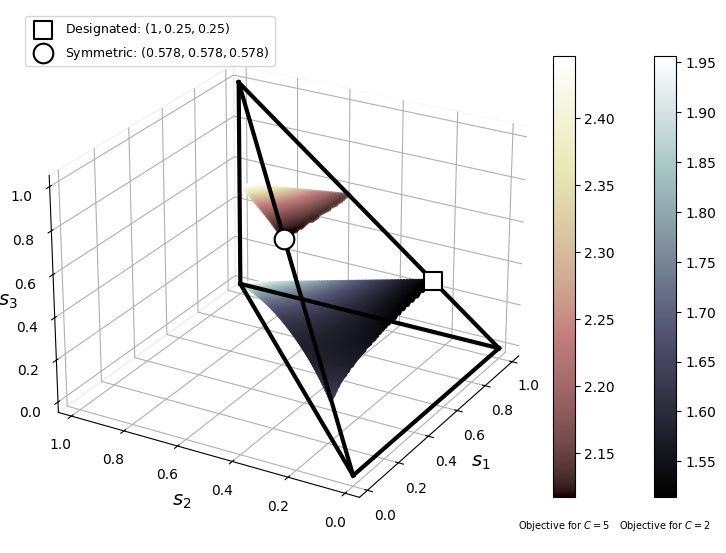

In [3]:
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d', computed_zorder=False)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

eps = 0.02
interior_mask2 = (eps <= Z2) & (Z2 <= Y2 - eps) & (Y2 <= X2 - eps) & (X2 <= 1 - eps)
interior_obj2 = obj2[interior_mask2]
interior_mask5 = (eps <= Z5) & (Z5 <= Y5 - eps) & (Y5 <= X5 - eps) & (X5 <= 1 - eps)
interior_obj5 = obj5[interior_mask5]

if len(interior_obj2) > 0:
    norm2 = colors.Normalize(vmin=float(interior_obj2.min()), vmax=float(interior_obj2.max()))
else:
    norm2 = colors.Normalize(vmin=float(obj2.min()), vmax=float(obj2.max()))
if len(interior_obj5) > 0:
    norm5 = colors.Normalize(vmin=float(interior_obj5.min()), vmax=float(interior_obj5.max()))
else:
    norm5 = colors.Normalize(vmin=float(obj5.min()), vmax=float(obj5.max()))

cmap2 = plt.get_cmap("bone")
cmap5 = plt.get_cmap("pink")

sc2 = ax.scatter(X2, Y2, Z2, c=obj2, cmap=cmap2, norm=norm2, s=7, alpha=0.95, zorder=1)
sc5 = ax.scatter(X5, Y5, Z5, c=obj5, cmap=cmap5, norm=norm5, s=7, alpha=0.60, zorder=2)

t = np.linspace(0,1,250)
ax.plot(t, 0*t, 0*t, color="black", lw=3, zorder=3)
ax.plot(t, t, 0*t, color="black", lw=3, zorder=3)
ax.plot(t, t, t, color="black", lw=3, zorder=3)
ax.plot(1+0*t, t, 0*t, color="black", lw=3, zorder=3)
ax.plot(1+0*t, t, t, color="black", lw=3, zorder=3)
ax.plot(1+0*t, 1+0*t, t, color="black", lw=3, zorder=3)

opt = 0.578
ax.scatter([1],[0.25],[0.25], s=150, marker='s', facecolor='white', edgecolor='black',
           linewidths=1.5, zorder=100, label=r'Designated: $(1, 0.25, 0.25)$')
ax.scatter([opt],[opt],[opt], s=200, marker='o', facecolor='white', edgecolor='black',
           linewidths=1.5, zorder=100, label=f'Symmetric: $({opt}, {opt}, {opt})$')

ax.legend(loc='upper left', fontsize=9)

ax.set_xlim(-0.05,1.05)
ax.set_ylim(-0.05,1.05)
ax.set_zlim(-0.05,1.05)

ax.set_xlabel(r"$s_1$", size=14)
ax.set_ylabel(r"$s_2$", size=14)
ax.xaxis.set_rotate_label(False)
ax.yaxis.set_rotate_label(False)
ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r"$s_3$", labelpad=-2, size=14)
ax.set_title("")

sm2 = ScalarMappable(norm=norm2, cmap=cmap2)
sm2.set_array([])
sm5 = ScalarMappable(norm=norm5, cmap=cmap5)
sm5.set_array([])

cbar2 = fig.colorbar(sm2, ax=ax, shrink=0.7, pad=0.01)
cbar2.ax.set_xlabel(r"Objective for $C=2$", fontsize=7, ha='center')
cbar2.ax.xaxis.set_label_coords(0.5, -0.05)

cbar5 = fig.colorbar(sm5, ax=ax, shrink=0.7, pad=0.0)
cbar5.ax.set_xlabel(r"Objective for $C=5$", fontsize=7, ha='center')
cbar5.ax.xaxis.set_label_coords(0.5, -0.05)

plt.subplots_adjust(left=0.05, right=0.88, bottom=0.05, top=0.95)
ax.view_init(elev=25, azim=210)
plt.show()

In [4]:
def c_star_lambert_B(alpha, B):
    delta = 1 - alpha
    arg = -delta * np.exp(-delta * (1 + B))
    w = lambertw(arg, k=-1).real
    t_star = -w / delta - 1 - B
    return np.exp(t_star)


alphas_sweep_fixed = np.arange(0.1, 0.91, 0.01)
bounds_B = {}
for B in [0.0]:
    bounds_B[B] = np.array([c_star_lambert_B(a, B) for a in alphas_sweep_fixed])
bounds_both = {}
for B in [0.0, 10.0]:
    bounds_both[B] = np.array([c_star_lambert_B(a, B) for a in alphas_sweep_fixed])

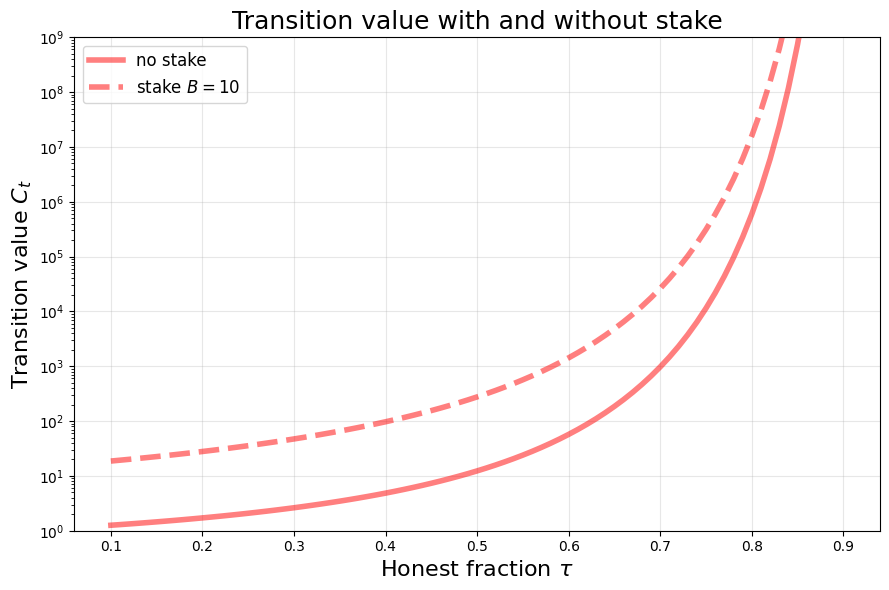

In [5]:
f, ax = plt.subplots(figsize=(9, 6))
ax.plot(alphas_sweep_fixed, bounds_both[0.0], linewidth=4, color='red', alpha=0.5, linestyle='-', label=r'no stake')
ax.plot(alphas_sweep_fixed, bounds_both[10.0], linewidth=4, color='red', alpha=0.5, linestyle='--', label=r'stake $B=10$')
ax.legend(fontsize=12)

ax.set_yscale('log')
ax.set_ylim(1, int(1e9))
ax.grid(alpha=0.3)
ax.set_xlabel(r'Honest fraction $\tau$', size=16)
ax.set_ylabel(r'Transition value $C_t$', size=16)
ax.set_title(r'Transition value with and without stake', size=18)
plt.tight_layout()
plt.show()

In [6]:
def D_alpha(C, alpha):
    f = lambda t: 1 + t - C * np.exp(-alpha * t)
    t_d = brentq(f, 0, 1e6)
    return 1 + t_d

def D_alpha_B(C, B, alpha):
    f = lambda t: 1 + t + B - C * np.exp(-alpha * t)
    t_d = brentq(f, 0, 1e6)
    return 1 + t_d

In [7]:
B = 1000
alphas = np.arange(1/2, .901, 0.01)
C_vals = np.arange(2, 5001, 5)

D_grid_noB = np.ones((len(alphas), len(C_vals)))
D_grid_B = np.ones((len(alphas), len(C_vals)))
for i, a in enumerate(alphas):
    for j, C in enumerate(C_vals):
        D_grid_noB[i, j] = D_alpha(C, a)
        if C > 1 + B:
            D_grid_B[i, j] = D_alpha_B(C, B, a)

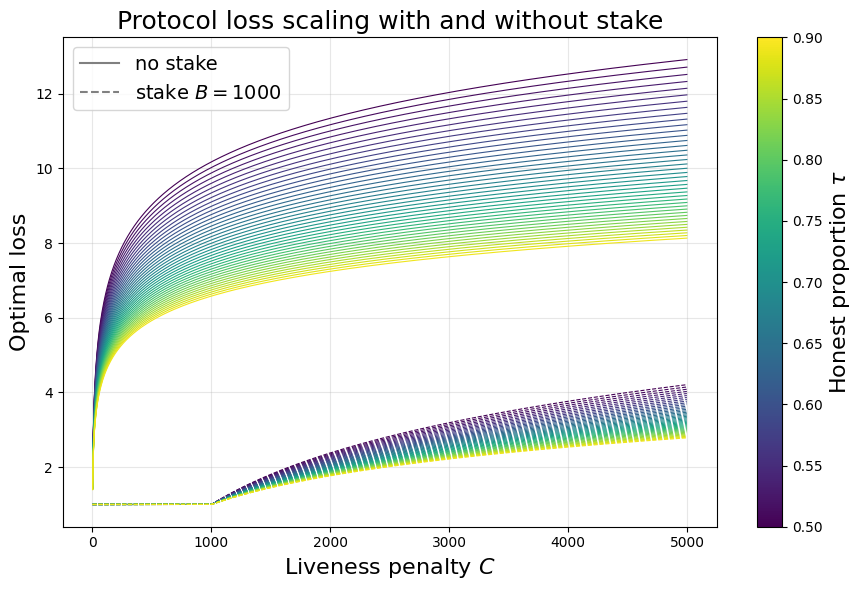

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
for i, a in enumerate(alphas):
    color = plt.cm.viridis(i / len(alphas))
    ax.plot(C_vals, D_grid_noB[i], color=color, lw=0.8, ls='-')
    ax.plot(C_vals, D_grid_B[i], color=color, lw=0.8, ls='--')

ax.plot([], [], color='gray', lw=1.5, ls='-', label=r'no stake')
ax.plot([], [], color='gray', lw=1.5, ls='--', label=rf'stake $B=1000$')
ax.legend(fontsize=14, loc='upper left')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(alphas[0], alphas[-1]))
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r'Honest proportion $\tau$', fontsize=16)

ax.set_xlabel(r'Liveness penalty $C$', fontsize=16)
ax.set_ylabel(r'Optimal loss', fontsize=16)
ax.set_title(rf'Protocol loss scaling with and without stake', size=18)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
def symmetric_eq_fixed(s, a, h_k, C, B):
    return (a + h_k) * s + C * (1 - s) ** (a + h_k) - C * (1 - s) ** h_k + B

def designated_eq_fixed(s, a, h_j, C, B):
    return 1 + (a + h_j - 1) * s - C * (1 - s) ** h_j + B

def symmetric_val_fixed(s, h_k, C, B):
    return C * (1 - s) ** h_k - B

def designated_val_fixed(s, h_j, C, B):
    return C * (1 - s) ** h_j - B

In [10]:
def best_vals_fixed(n, a, C, B):
    h = n - a
    best_d = np.inf
    best_s = np.inf

    for h_k in range(1, h + 1):
        k = a + h_k
        def sym_obj(s, k=k, h_k=h_k):
            term1 = k * s + C * (1 - s) ** k
            term2 = C * (1 - s) ** h_k - B
            return max(term1, term2)
        res = minimize_scalar(sym_obj, bounds=(0, 1), method='bounded')
        if res.fun < best_s:
            best_s = res.fun

        def des_obj(s, k=k, h_k=h_k):
            term1 = 1 + (k - 1) * s
            term2 = C * (1 - s) ** h_k - B
            return max(term1, term2)
        res = minimize_scalar(des_obj, bounds=(0, 1), method='bounded')
        if res.fun < best_d:
            best_d = res.fun

    return best_d, best_s

In [11]:
def find_crossover_C_fixed(n, a, B, tol=1e-2):
    d_base, s_base = best_vals_fixed(n, a, 1.01, B)
    if s_base < d_base:
        return 1.01

    hi = None
    # check in powers of 10. 
    for p in range(1, 16):
        C_test = 10.0 ** p
        d_val, s_val = best_vals_fixed(n, a, C_test, B)
        if s_val < d_val:
            hi = C_test
            lo = 10.0 ** (p - 1) if p > 1 else 1.01
            break
    if hi is None:
        return None

    while hi - lo > tol:
        mid = (lo + hi) / 2
        d_val, s_val = best_vals_fixed(n, a, mid, B)
        if s_val < d_val:
            hi = mid
        else:
            lo = mid
    return hi

In [12]:
Bs_fixed = [0., 10.]
ns_fixed = [40, 60, 80, 100]
alphas_sweep_fixed = np.arange(0.1, 0.91, 0.01)

results_dict_both = {}

for B in Bs_fixed:
    results_array = np.full((len(ns_fixed), len(alphas_sweep_fixed)), np.nan)
    for i, n_val in enumerate(ns_fixed):
        for j, alpha in enumerate(tqdm(alphas_sweep_fixed, desc=f"B={B}, n={n_val}")):
            a = int(round((1 - alpha) * n_val))
            if a < 1 or n_val - a < 1:
                continue
            results_array[i, j] = find_crossover_C_fixed(n_val, a, B)
    results_dict_both[B] = results_array

print("Done.", {B: arr.shape for B, arr in results_dict_both.items()})

B=10.0, n=100: 100%|██████████| 81/81 [00:15<00:00,  5.24it/s]

Done. {0.0: (4, 81), 10.0: (4, 81)}


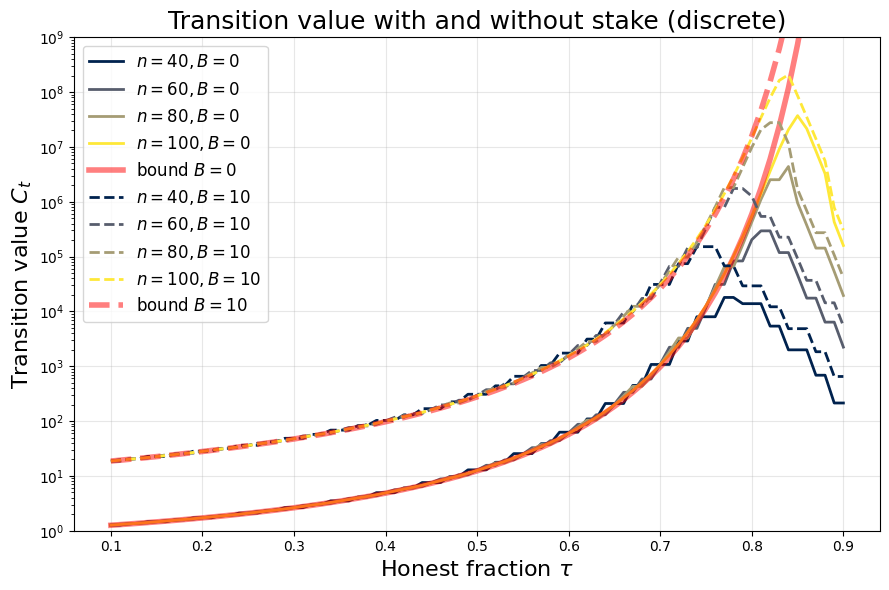

In [13]:
cmap = plt.cm.cividis
norm = mpl.colors.Normalize(vmin=ns_fixed[0], vmax=ns_fixed[-1])

f, ax = plt.subplots(figsize=(9, 6))

for i, n_val in enumerate(ns_fixed):
    color = cmap(norm(n_val))
    ax.plot(alphas_sweep_fixed, results_dict_both[0.0][i], color=color,
            linewidth=2, alpha=1, linestyle='-', label=f'$n={n_val}, B=0$')
ax.plot(alphas_sweep_fixed, bounds_both[0.0], linewidth=4, color='red', alpha=0.5, linestyle='-', label=r'bound $B=0$')

for i, n_val in enumerate(ns_fixed):
    color = cmap(norm(n_val))
    ax.plot(alphas_sweep_fixed, results_dict_both[10.0][i], color=color,
            linewidth=2, alpha=1, linestyle='--', label=f'$n={n_val}, B=10$')
ax.plot(alphas_sweep_fixed, bounds_both[10.0], linewidth=4, color='red', alpha=0.5, linestyle='--', label=r'bound $B=10$')

ax.legend(fontsize=12)
ax.set_yscale('log')
ax.set_ylim(1, int(1e9))
ax.grid(alpha=0.3)
ax.set_xlabel(r'Honest fraction $\tau$', size=16)
ax.set_ylabel(r'Transition value $C_t$', size=16)
ax.set_title(r'Transition value with and without stake (discrete)', size=18)
plt.tight_layout()
plt.show()

In [14]:
alphas_sweep_fixed

array([0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 ,
       0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31,
       0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42,
       0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53,
       0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64,
       0.65, 0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75,
       0.76, 0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86,
       0.87, 0.88, 0.89, 0.9 ])

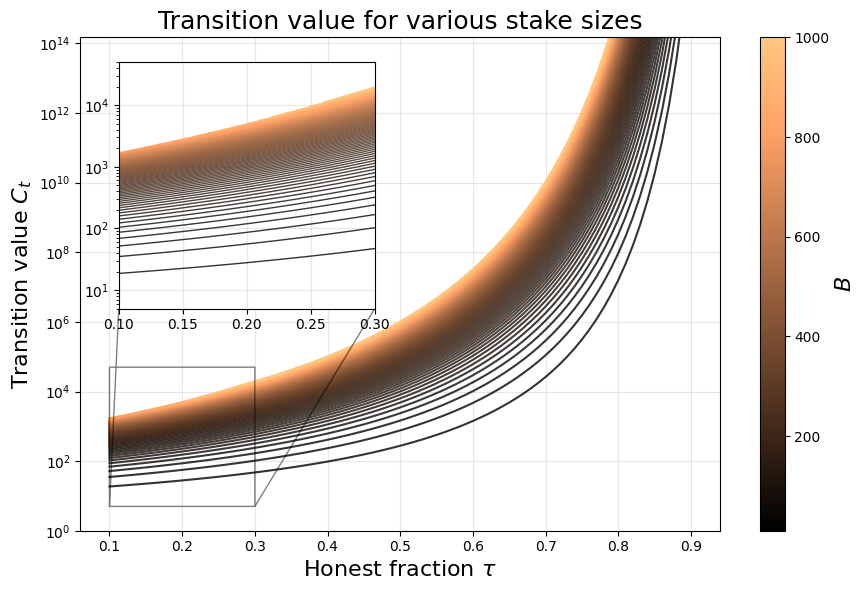

In [15]:
f, ax = plt.subplots(figsize=(9, 6))
B_range = np.arange(10, 1001, 10)
cmap_copper = plt.cm.copper
norm_B = mpl.colors.Normalize(vmin=B_range[0], vmax=B_range[-1])
ax_inset = ax.inset_axes([0.06, 0.45, 0.4, 0.5])

for B in B_range:
    c_stars = np.array([c_star_lambert_B(a, B) for a in alphas_sweep_fixed])
    ax.plot(alphas_sweep_fixed, c_stars , color=cmap_copper(norm_B(B)), linewidth=1.5, alpha=0.8)
    ax_inset.plot(alphas_sweep_fixed, c_stars, color=cmap_copper(norm_B(B)), linewidth=1.0, alpha=0.8)

ax.set_yscale('log')
ax.set_ylim(1, float(15e13))
ax.grid(alpha=0.3)
ax.set_xlabel(r'Honest fraction $\tau$', size=16)
ax.set_ylabel(r'Transition value $C_t$', size=16)
ax.set_title(r'Transition value for various stake sizes', size=18)

sm = mpl.cm.ScalarMappable(cmap=cmap_copper, norm=norm_B)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('$B$', size=16)
       
ax_inset.set_xlim(0.1, 0.3)
ax_inset.set_ylim(5, int(5e4))
ax_inset.set_yscale('log')
ax_inset.grid(alpha=0.3)
ax.indicate_inset_zoom(ax_inset, edgecolor='black', alpha=0.5)

plt.tight_layout()
plt.show()

In [16]:
def compute_D_star(h, a, C):
    best_val = np.inf
    best_hj = None
    best_s = None
    
    for h_j in range(1, h + 1):
        def constraint(s, _h_j=h_j):
            return 1 + (_h_j + a - 1) * s - C * (1 - s)**_h_j
        
        try:
            s_star = brentq(constraint, 1e-10, 1 - 1e-10)
        except ValueError:
            continue
        
        val = 1 + (h_j + a - 1) * s_star
        
        if val < best_val:
            best_val = val
            best_hj = h_j
            best_s = s_star
    
    return best_val, best_hj, best_s


def compute_S_star(h, a, C):
    best_val = np.inf
    best_hk = None
    best_s = None
    
    for h_k in range(1, h + 1):
        def constraint(s, _h_k=h_k):
            return (_h_k + a) * s + C * (1 - s)**(_h_k + a) - C * (1 - s)**_h_k
        
        try:
            s_star = brentq(constraint, 1e-10, 1 - 1e-10)
        except ValueError:
            continue
        
        val = (h_k + a) * s_star + C * (1 - s_star)**(h_k + a)
        
        if val < best_val:
            best_val = val
            best_hk = h_k
            best_s = s_star
    
    return best_val, best_hk, best_s

def compute_D_hat(h, a, C):
    best_val = np.inf
    best_hj = None
    best_s = None
    
    for h_j in range(1, h + 1):
        n_j = h_j + a
        def constraint(s, _h_j=h_j, _n_j=n_j):
            return 1 + (_n_j - 1) * s - C * (1 - s)**_h_j
        
        try:
            s_star = brentq(constraint, 1e-10, 1 - 1e-10)
        except ValueError:
            continue
        
        val = C * (1 - s_star)**h_j
        
        if val < best_val:
            best_val = val
            best_hj = h_j
            best_s = s_star
    
    return best_val, best_hj, best_s


def solve_LP2(h_k, a, C, s):
    n_k = h_k + a
    num_vars = n_k + 1
    
    c_obj = np.zeros(num_vars)
    c_obj[-1] = 1
    
    A_ub_rows = []
    b_ub_vals = []
    
    for j in range(1, a + 1):
        row = np.zeros(num_vars)
        for i in range(h_k + 1):
            m = j + i
            if 1 <= m <= n_k:
                row[m - 1] += scipy_comb(h_k, i, exact=True) * s**i * (1 - s)**(h_k - i)
        row[-1] = -1
        A_ub_rows.append(row)
        b_ub_vals.append(0.0)
    
    row = np.zeros(num_vars)
    for i in range(1, h_k + 1):
        row[i - 1] += scipy_comb(h_k, i, exact=True) * s**i * (1 - s)**(h_k - i)
    row[-1] = -1
    A_ub_rows.append(row)
    b_ub_vals.append(-C * (1 - s)**h_k)
    
    A_ub = np.array(A_ub_rows)
    b_ub = np.array(b_ub_vals)
    
    A_eq = np.zeros((1, num_vars))
    for i in range(1, n_k + 1):
        A_eq[0, i - 1] = scipy_comb(n_k - 1, i - 1, exact=True) * s**(i - 1) * (1 - s)**(n_k - i) / i
    b_eq = np.array([1.0])
    
    bounds = [(0, None)] * n_k + [(None, None)]
    
    res = linprog(c_obj, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    return res.fun if res.success else np.inf


def compute_S_hat(h, a, C):
    best_val = np.inf
    best_hk = None
    best_s = None
    
    for h_k in range(1, h + 1):
        s_grid = np.linspace(0.01, 0.99, 80)
        best_s_hk = None
        best_val_hk = np.inf
        
        for s in s_grid:
            t = solve_LP2(h_k, a, C, s)
            if t < best_val_hk:
                best_val_hk = t
                best_s_hk = s
        
        # Refine
        if best_s_hk is not None:
            lo = max(0.001, best_s_hk - 0.05)
            hi = min(0.999, best_s_hk + 0.05)
            
            def lp_obj(s, _h_k=h_k):
                return solve_LP2(_h_k, a, C, s)
            
            res = minimize_scalar(lp_obj, bounds=(lo, hi), method='bounded',
                                  options={'xatol': 1e-8})
            if res.fun < best_val_hk:
                best_val_hk = res.fun
                best_s_hk = res.x
        
        if best_val_hk < best_val:
            best_val = best_val_hk
            best_hk = h_k
            best_s = best_s_hk
    
    return best_val, best_hk, best_s

In [17]:
def classify_regime(D_star, S_star, D_hat, S_hat, tol=1e-4):
    if abs(D_star - D_hat) < tol and D_hat < S_star - tol:
        return 1
    elif S_star < D_hat - tol and D_hat < S_hat - tol:
        return 2
    elif S_star < S_hat - tol and S_hat < D_hat - tol:
        return 3
    elif abs(S_star - S_hat) < tol:
        return 4
    return 0


def eval_regime(C, h, a):
    D_star_val = compute_D_star(h, a, C)[0]
    S_star_val = compute_S_star(h, a, C)[0]
    D_hat_val = compute_D_hat(h, a, C)[0]

    tol = 1e-4
    if abs(D_star_val - D_hat_val) < tol and D_hat_val < S_star_val - tol:
        return 1, D_star_val, S_star_val, D_hat_val, np.inf

    S_hat_val = compute_S_hat(h, a, C)[0]
    regime = classify_regime(D_star_val, S_star_val, D_hat_val, S_hat_val)
    return regime, D_star_val, S_star_val, D_hat_val, S_hat_val


def bisect_boundary(C_lo, C_hi, h, a, regime_lo, tol=1e-3):
    while C_hi - C_lo > tol:
        C_mid = (C_lo + C_hi) / 2
        r_mid = eval_regime(C_mid, h, a)[0]
        if r_mid == regime_lo or r_mid == 0:
            C_lo = C_mid
        else:
            C_hi = C_mid
    return (C_lo + C_hi) / 2


def find_regime_boundaries(n, h, C_max=500, coarse_step=1.0, tol=1e-3, label=None):
    a = n - h
    tag = label or f"(n={n},h={h})"

    C_coarse = np.arange(1.01, C_max, coarse_step)
    regimes = []
    for idx, C in enumerate(C_coarse):
        if idx % 10 == 0:
            print(f"  {tag}: coarse scan C={C:.1f}/{C_max}", flush=True)
        r = eval_regime(C, h, a)[0]
        regimes.append((C, r))
        if r == 4:
            print(f"  {tag}: reached regime 4 at C={C:.1f}, stopping scan", flush=True)
            break

    transitions = []
    prev_C, prev_r = regimes[0]
    for C, r in regimes[1:]:
        if r != prev_r:
            transitions.append((prev_C, C, prev_r, r))
        prev_C, prev_r = C, r

    print(f"  {tag}: found {len(transitions)} transitions, refining...", flush=True)

    boundaries = []
    for C_lo, C_hi, r_lo, r_hi in transitions:
        if r_lo == 0:
            for Ct, rt in reversed(regimes):
                if Ct < C_lo and rt != 0:
                    r_lo = rt
                    break
        if r_hi == 0:
            for Ct, rt in regimes:
                if Ct > C_hi and rt != 0:
                    r_hi = rt
                    break

        if r_lo != 0 and r_hi != 0 and r_lo != r_hi:
            C_boundary = bisect_boundary(C_lo, C_hi, h, a, r_lo, tol=tol)
            boundaries.append((r_lo, r_hi, C_boundary))

    seen = set()
    unique_boundaries = []
    for r1, r2, C_b in boundaries:
        key = (r1, r2)
        if key not in seen:
            seen.add(key)
            unique_boundaries.append((r1, r2, C_b))

    print(f"  {tag}: DONE")
    for r1, r2, C_b in unique_boundaries:
        vals = eval_regime(C_b, h, a)
        print(f"    Regime {r1} -> {r2} at C = {C_b:.4f}")
        print(f"      D*={vals[1]:.6f}, S*={vals[2]:.6f}, "
              f"D_hat={vals[3]:.6f}, S_hat={vals[4]:.6f}")

    return unique_boundaries

In [18]:
from concurrent.futures import ThreadPoolExecutor, as_completed

pairs = [
    (3, 1),
    (4, 1), (4, 2),
    (5, 1), (5, 2), (5, 3),
    (6, 1), (6, 2), (6, 3), (6, 4),
    (7, 1), (7, 2), (7, 3), (7, 4), (7, 5),
]

all_boundaries = {}

def worker(n, h):
    boundaries = find_regime_boundaries(n, h, C_max=100, coarse_step=2.0, tol=1e-3)
    return (n, h), boundaries

with ThreadPoolExecutor(max_workers=len(pairs)) as executor:
    futures = {executor.submit(worker, n, h): (n, h) for n, h in pairs}
    for future in as_completed(futures):
        key, boundaries = future.result()
        all_boundaries[key] = boundaries

  (n=3,h=1): coarse scan C=1.0/100
  (n=4,h=1): coarse scan C=1.0/100
  (n=4,h=2): coarse scan C=1.0/100
  (n=5,h=1): coarse scan C=1.0/100
  (n=5,h=2): coarse scan C=1.0/100
  (n=5,h=3): coarse scan C=1.0/100
  (n=6,h=1): coarse scan C=1.0/100
  (n=6,h=2): coarse scan C=1.0/100
  (n=6,h=3): coarse scan C=1.0/100
  (n=6,h=4): coarse scan C=1.0/100
  (n=7,h=1): coarse scan C=1.0/100
  (n=7,h=2): coarse scan C=1.0/100
  (n=7,h=3): coarse scan C=1.0/100
  (n=7,h=4): coarse scan C=1.0/100
  (n=7,h=5): coarse scan C=1.0/100
  (n=7,h=4): coarse scan C=21.0/100
  (n=3,h=1): reached regime 4 at C=5.0, stopping scan
  (n=3,h=1): found 1 transitions, refining...
  (n=6,h=1): reached regime 4 at C=7.0, stopping scan
  (n=5,h=3): reached regime 4 at C=9.0, stopping scan
  (n=6,h=1): found 3 transitions, refining...
  (n=5,h=3): found 1 transitions, refining...
  (n=4,h=1): reached regime 4 at C=5.0, stopping scan
  (n=4,h=1): found 2 transitions, refining...
  (n=4,h=2): reached regime 4 at C=7.0,

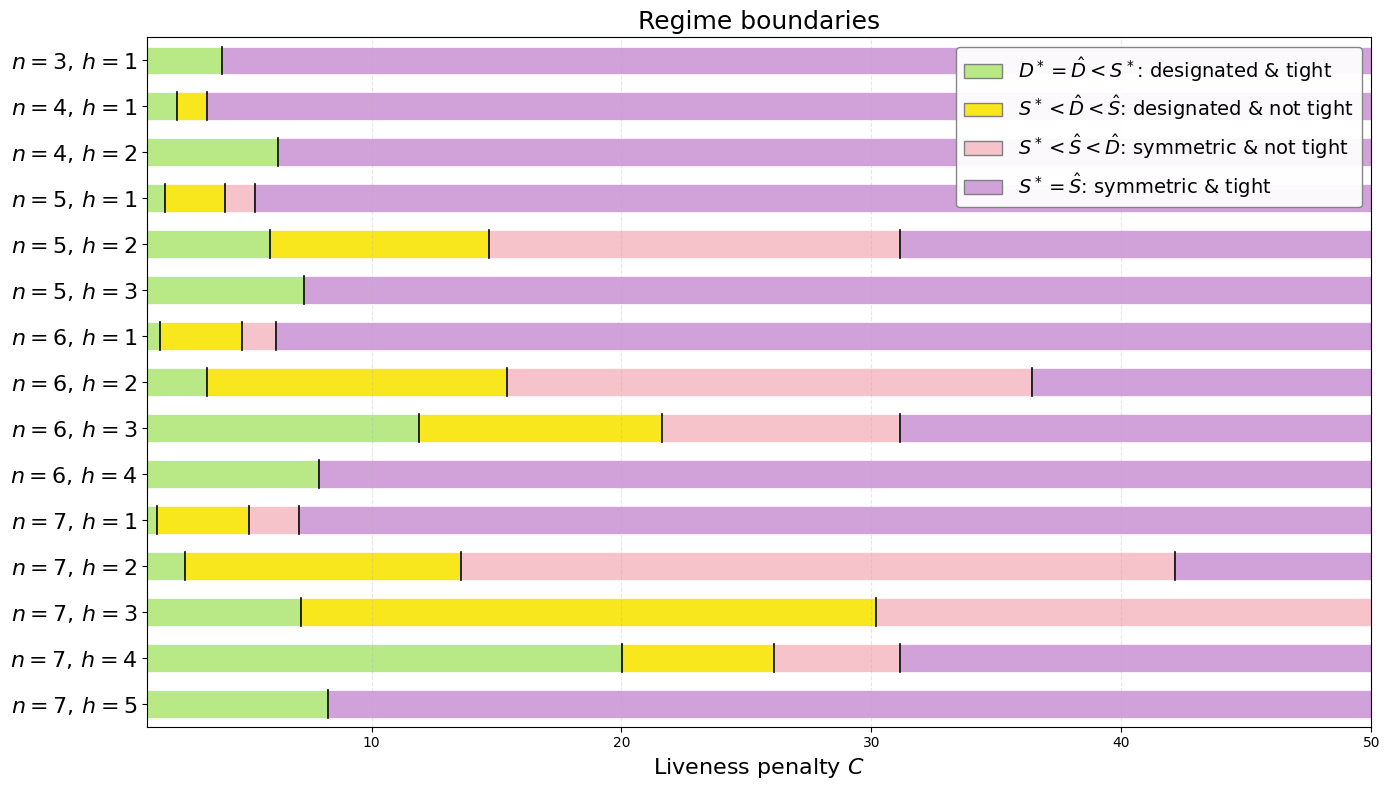

In [19]:
import matplotlib.patches as mpatches

regime_colors = {
    1: '#B8E986',
    2: '#F8E71C',
    3: '#F7C3CA',
    4: '#D1A1DA',
}
regime_labels = {
    1: r'$D^*=\hat{D} < S^*$: designated & tight',
    2: r'$S^* < \hat{D} < \hat{S}$: designated & not tight',
    3: r'$S^* < \hat{S} < \hat{D}$: symmetric & not tight',
    4: r'$S^*=\hat{S}$: symmetric & tight',
}

plot_min = 1.0
plot_max = 50
height = 0.6

fig, ax = plt.subplots(figsize=(14, 8))

y_labels = []
for idx, (n, h) in enumerate(pairs):
    y = len(pairs) - 1 - idx  # plot top-to-bottom
    y_labels.append(f'$n={n},\\, h={h}$')
    
    bs = all_boundaries.get((n, h), [])
    
    segments = []
    prev_C = plot_min
    for r1, r2, C_b in sorted(bs, key=lambda x: x[2]):
        segments.append((prev_C, C_b, r1))
        prev_C = C_b
    last_regime = bs[-1][1] if bs else 1
    segments.append((prev_C, plot_max, last_regime))
    
    for C_lo, C_hi, regime in segments:
        c_lo_clip = max(C_lo, plot_min)
        c_hi_clip = min(C_hi, plot_max)
        if c_hi_clip <= c_lo_clip:
            continue
        color = regime_colors.get(regime, '#bdc3c7')
        ax.barh(y, c_hi_clip - c_lo_clip, left=c_lo_clip, height=height,
                color=color, edgecolor='white', linewidth=0.5)
    
    for r1, r2, C_b in bs:
        if C_b <= plot_max:
            ax.plot([C_b, C_b], [y - height/2, y + height/2],
                    color='black', linewidth=1.2, zorder=3)

ax.set_yticks(range(len(pairs)))
ax.set_yticklabels(list(reversed(y_labels)), fontsize=16)
ax.set_xlabel('Liveness penalty $C$', fontsize=16)
ax.set_xlim(plot_min, plot_max)
ax.set_ylim(-0.5, len(pairs) - 0.5)
ax.set_title('Regime boundaries', fontsize=18)

legend_handles = [mpatches.Patch(facecolor=regime_colors[r], edgecolor='grey',
                                  label=regime_labels[r]) for r in [1, 2, 3, 4]]
ax.legend(handles=legend_handles, loc=1, fontsize=14, framealpha=0.95, edgecolor='grey')

ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()